# 03 — Train M1: OEE Forecasting (Keras ANN Ensemble)

**Goal:** Train a 5-model Keras Sequential ANN ensemble to predict `Predicted_OEE_t10`.

**Output:** `models/m1_oee_seed*.keras` (×5) + `models/scaler_m1.pkl`

## Step 1 — Setup & Imports

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, json, joblib, os
from pathlib import Path
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

np.random.seed(42)
tf.random.set_seed(42)
sns.set_style("whitegrid")

ROOT = Path.cwd().parent if Path.cwd().name == "ml_model" else Path.cwd()
MODEL_DIR = ROOT / "ml_model" / "models"
PLOT_DIR = ROOT / "ml_model" / "plots"
MODEL_DIR.mkdir(exist_ok=True)
PLOT_DIR.mkdir(exist_ok=True)
print(f"Model dir: {MODEL_DIR}")


Model dir: E:\Projects\iot-aiml-project\ml_model\models


## Step 2 — Load & Prepare Data

In [2]:
df = pd.read_csv(ROOT / "ml_model" / "data" / "syn_oee_10k.csv")
df["Production_End_Time"] = pd.to_datetime(df["Production_End_Time"])
df = df.sort_values("Production_End_Time").reset_index(drop=True)
print(f"Loaded {len(df)} rows, {df['Batch_PartNo'].nunique()} batches")

# Features + one-hot state
BASE = ["Availability","Performance","Quality","Current_OEE",
        "Current_Speed_pct","DownTime_sec","OEE_Delta",
        "Part_SLNo","_pos_ratio"]
LAGS = ["OEE_lag1","OEE_roll5_mean","OEE_trend3"]
state_dummies = pd.get_dummies(df['_state'], prefix='state')
df = pd.concat([df, state_dummies], axis=1)
FEATURES = BASE + LAGS + list(state_dummies.columns)
TARGET = "Predicted_OEE_t10"
print(f"Features ({len(FEATURES)}): {FEATURES}")


Loaded 10000 rows, 255 batches
Features (17): ['Availability', 'Performance', 'Quality', 'Current_OEE', 'Current_Speed_pct', 'DownTime_sec', 'OEE_Delta', 'Part_SLNo', '_pos_ratio', 'OEE_lag1', 'OEE_roll5_mean', 'OEE_trend3', 'state_HIGH_LOAD', 'state_MAJOR_STOPPAGE', 'state_MINOR_STOPPAGE', 'state_NORMAL', 'state_RECOVERY']


## Step 3 — Temporal Train/Test Split & Scale

In [3]:
split = int(len(df) * 0.8)
train_df, test_df = df.iloc[:split].copy(), df.iloc[split:].copy()

X_train = train_df[FEATURES].values
y_train = train_df[TARGET].values
X_test  = test_df[FEATURES].values
y_test  = test_df[TARGET].values

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
joblib.dump(scaler, MODEL_DIR / "scaler_m1.pkl")

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"y range: [{y_train.min()}, {y_train.max()}]")


Train: (8000, 17), Test: (2000, 17)
y range: [74, 79]


## Step 4 — Build Keras ANN (Matching Old Architecture)

In [4]:
def build_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'), Dropout(0.2),
        Dense(64, activation='relu'), Dropout(0.1),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

m = build_model(len(FEATURES))
m.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,673 (49.50 KB)

 Trainable params: 12,673 (49.50 KB)

 Non-trainable params: 0 (0.00 B)

## Step 5 — Train One Model (Quick Validation)

In [5]:
es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
h = build_model(len(FEATURES)).fit(X_train, y_train, validation_split=0.2,
                                    batch_size=32, epochs=150, callbacks=[es], verbose=1)
val_mae = min(h.history['val_mae'])
print(f"Validation MAE: {val_mae:.4f}")


Epoch 1/150



  1/200 ━━━━━━━━━━━━━━━━━━━━ 5:48 2s/step - loss: 6114.5464 - mae: 78.1881


 24/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5921.5634 - mae: 76.9151 


 48/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5600.1525 - mae: 74.5831


 71/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5114.5477 - mae: 70.1814

...


133/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.4659 - mae: 2.1827


160/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.3981 - mae: 2.1700


186/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.3493 - mae: 2.1606


200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.0502 - mae: 2.1036 - val_loss: 3.7977 - val_mae: 1.9106


Validation MAE: 0.4475


## Step 6 — Plot Training History

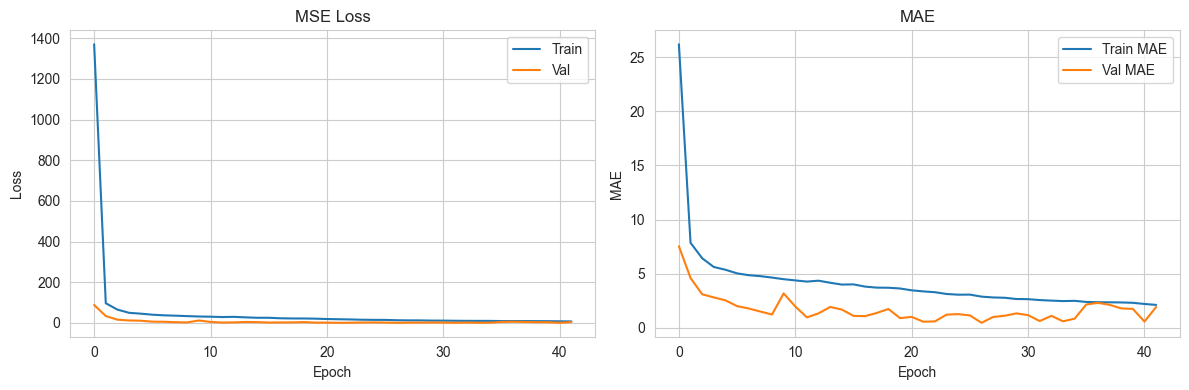

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(h.history['loss'], label='Train')
ax1.plot(h.history['val_loss'], label='Val')
ax1.set(xlabel='Epoch', ylabel='Loss', title='MSE Loss'); ax1.legend(); ax1.grid(True)
ax2.plot(h.history['mae'], label='Train MAE')
ax2.plot(h.history['val_mae'], label='Val MAE')
ax2.set(xlabel='Epoch', ylabel='MAE', title='MAE'); ax2.legend(); ax2.grid(True)
fig.tight_layout(); fig.savefig(PLOT_DIR / "m1_training_history.png", dpi=120); plt.show()


## Step 7 — Train 5-Model Ensemble

In [7]:
SEEDS = [0, 1, 2, 3, 4]
ensemble_preds = []
print("Training 5-model ensemble...")
for seed in SEEDS:
    tf.random.set_seed(seed)
    np.random.seed(seed)
    model = build_model(len(FEATURES))
    es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    model.fit(X_train, y_train, validation_split=0.2, batch_size=32,
              epochs=200, callbacks=[es], verbose=0)
    model.save(MODEL_DIR / f"m1_oee_seed{seed}.keras")
    preds = model.predict(X_test, verbose=0).ravel()
    ensemble_preds.append(preds)
    r2 = r2_score(y_test, preds)
    print(f"  seed={seed}: test R²={r2:.4f}")

y_pred = np.mean(ensemble_preds, axis=0)
y_std  = np.std(ensemble_preds, axis=0)
print(f"Ensemble test R²: {r2_score(y_test, y_pred):.4f}")


Training 5-model ensemble...


  seed=0: test R²=0.9074


  seed=1: test R²=1.0000


  seed=2: test R²=0.5526


  seed=3: test R²=0.9609


  seed=4: test R²=0.9284
Ensemble test R²: 0.9678


## Step 8 — Evaluation & Confidence

=== M1 Ensemble Results ===
  R² test:       0.9678
  MAE test:      0.17 OEE pts
  Avg confidence: 93.3%
  Min confidence: 64.1%


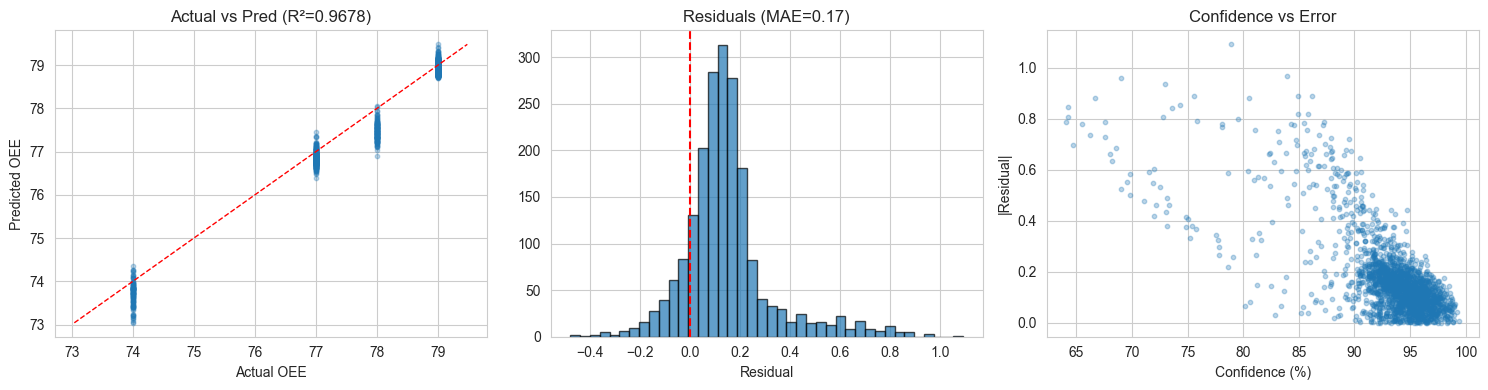

In [8]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
oee_range = max(y_test.max() - y_test.min(), 1)
conf = np.clip(100 * (1 - y_std / oee_range), 0, 100)

print("=== M1 Ensemble Results ===")
print(f"  R² test:       {r2:.4f}")
print(f"  MAE test:      {mae:.2f} OEE pts")
print(f"  Avg confidence: {conf.mean():.1f}%")
print(f"  Min confidence: {conf.min():.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(y_test, y_pred, alpha=0.3, s=10)
m = min(y_test.min(), y_pred.min()); M = max(y_test.max(), y_pred.max())
axes[0].plot([m, M], [m, M], "r--", lw=1)
axes[0].set(xlabel='Actual OEE', ylabel='Predicted OEE', title=f'Actual vs Pred (R²={r2:.4f})')
axes[0].grid(True)

res = y_test - y_pred
axes[1].hist(res, bins=40, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', ls='--')
axes[1].set(xlabel='Residual', title=f'Residuals (MAE={mae:.2f})')
axes[1].grid(True)

axes[2].scatter(conf, np.abs(res), alpha=0.3, s=10)
axes[2].set(xlabel='Confidence (%)', ylabel='|Residual|', title='Confidence vs Error')
axes[2].grid(True)

fig.tight_layout(); fig.savefig(PLOT_DIR / "m1_ensemble_performance.png", dpi=120); plt.show()


## Step 9 — Verify Saved Models

In [9]:
from tensorflow.keras.models import load_model
preds = []
for seed in SEEDS:
    m = load_model(MODEL_DIR / f"m1_oee_seed{seed}.keras")
    preds.append(m.predict(X_test[:5], verbose=0).ravel())
reloaded = np.mean(preds, axis=0)
print(f"Origin:  {y_pred[:5].round(2)}")
print(f"Reload:  {reloaded.round(2)}")
print(f"Match:   {np.allclose(y_pred[:5], reloaded, atol=1e-4)}")


Origin:  [78.73 78.78 78.74 78.81 76.69]
Reload:  [78.73 78.78 78.74 78.81 76.69]
Match:   True


## Step 10 — Summary

In [ ]:
print("=" * 60)
print("M1 OEE Forecasting - Keras ANN Ensemble Summary")
print("=" * 60)
print(f"Training rows:   {len(train_df)}")
print(f"Testing rows:    {len(test_df)}")
print(f"Features:        {len(FEATURES)}")
print("Architecture:    128->64->32 (Dropout 0.2/0.1)")
print(f"Ensemble:        {len(SEEDS)} models (seeds {SEEDS})")
print("")
print(f"R² test:         {r2:.4f}")
print(f"MAE test:        {mae:.2f} OEE pts")
print(f"Avg confidence:  {conf.mean():.1f}%")
print("")
print("Target: Predicted_OEE_t10")
print(f"Models: {MODEL_DIR / 'm1_oee_seed*.keras'}")
print(f"Scaler: {MODEL_DIR / 'scaler_m1.pkl'}")


M1 OEE Forecasting - Keras ANN Ensemble Summary
Training rows:   8000
Testing rows:    2000
Features:        17
Architecture:    128->64->32 (Dropout 0.2/0.1)
Ensemble:        5 models (seeds [0, 1, 2, 3, 4])

R² test:         0.9678
MAE test:        0.17 OEE pts
Avg confidence:  93.3%

Target: Predicted_OEE_t10
Models: E:\Projects\iot-aiml-project\ml_model\models\m1_oee_seed*.keras
Scaler: E:\Projects\iot-aiml-project\ml_model\models\scaler_m1.pkl
